In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import torch
import scipy as sp

import sys
sys.path.append("../")
import steamboat as sf
import steamboat.tools

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['font.family'] = 'arial'
matplotlib.rcParams["legend.handletextpad"] = 0.
matplotlib.rcParams["legend.labelspacing"] = .3
pltkw = dict(bbox_inches='tight', transparent=True)
from joblib import Parallel, delayed
import seaborn as sns

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [ ]:
adata = sc.read_h5ad("../data/Ex5_slide_tags_human_tonsil/HumanTonsil_2000.h5ad")

In [3]:
adata.obs['global'] = 0
adatas = sf.prep_adatas([adata], norm=False, log1p=False, n_neighs=8)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

  0%|          | 0/1 [00:00<?, ?it/s]

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
device = 'cuda'
sf.set_random_seed(0)
model = sf.Steamboat(adata.var_names.tolist(), n_heads=60, n_scales=3)
model = model.to(device)

In [5]:
# model.fit(dataset.to(device), entry_masking_rate=0.1, feature_masking_rate=0.1,
#             max_epoch=10000, 
#             loss_fun=torch.nn.MSELoss(reduction='sum'),
#             opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=2e-5, report_per=1000, stop_tol=250, device=device)

# torch.save(model.state_dict(), 'saved_models/tonsil.pth')

# [2025-10-02 12:25:00,171::train::INFO] Epoch 1: train_loss 393.33020
# [2025-10-02 12:25:06,773::train::INFO] Epoch 1001: train_loss 206.91405
# [2025-10-02 12:25:13,339::train::INFO] Epoch 2001: train_loss 203.47221
# [2025-10-02 12:25:19,166::train::INFO] Epoch 2886: train_loss 203.11626
# [2025-10-02 12:25:19,167::train::INFO] Stopping criterion met.

In [ ]:
model.load_state_dict(torch.load('../data/saved_models/tonsil.pth'))

<All keys matched successfully>

In [7]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
sf.tools.gather_obs(adata, adatas)

  0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 5778 × 2000
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', 'global'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap', 'spatial_neighbors', 'global_k_0'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_recon', 'q', 'local_k', 'global_k_0', 'attn', 'ego_attn', 'local_attn', 'global_attn_0', 'global_attn'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'local_attn_0', 'local_attn_1', 'local_attn_2', 'local_attn_3', 'local_attn_4', 'local_attn_5', 'local_attn_6', 'local_attn_7', 'local_attn_8', 'local_attn_9', 'local_attn_10', 'local_attn_11', 'local_attn_12', 'local_attn_13', 'local_attn_14', 'local_attn_15', 'local_attn_16', '

In [8]:
var = sf.tools.calc_var(model)
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
adata.obs

,biosample_id,donor_id,species,species__ontology_label,disease,disease__ontology_label,organ,organ__ontology_label,library_preparation_protocol,library_preparation_protocol__ontology_label,sex,cluster,global
AAACCCAAGCGCCTTG-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,T_CD4,0
AAACCCAAGTGGACGT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,plasma,0
AAACCCACAGAAGTGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0
AAACCCAGTCATTGCA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_naive,0
AAACCCATCATCGCAA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_memory,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAGGGACTA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0
TTTGTTGCATTGTAGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,plasma,0
TTTGTTGGTACCACGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0
TTTGTTGGTCTGTCCT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,T_CD4,0


In [10]:
adata.obs['cluster'].unique()

['T_CD4', 'plasma', 'B_germinal_center', 'B_naive', 'B_memory', ..., 'FDC', 'T_CD8', 'pDC', 'myeloid', 'T_double_neg']
Length: 13
Categories (13, object): ['B_germinal_center', 'B_memory', 'B_naive', 'FDC', ..., 'mDC', 'myeloid', 'pDC', 'plasma']

In [ ]:
adata.obs = pd.read_csv('../data/Ex5_slide_tags_human_tonsil/tonsil_spatial_domain_all_methods.csv', index_col=0)

In [12]:
adata.obs

,biosample_id,donor_id,species,species__ontology_label,disease,disease__ontology_label,organ,organ__ontology_label,library_preparation_protocol,library_preparation_protocol__ontology_label,...,global,std_attn_leiden,steamboat_spatial_domain_2,steamboat_spatial_domain_2_labeled,banksy,banksy_labeled,SEDR,SEDR_labeled,stagate,stagate_labeled
AAACCCAAGCGCCTTG-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,2,1,TZ,0,TZ/MZ,1,GC/TZ,0,TZ
AAACCCAAGTGGACGT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,4,0,GC,1,GC,1,GC/TZ,2,GC
AAACCCACAGAAGTGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,1,0,GC,1,GC,1,GC/TZ,2,GC
AAACCCAGTCATTGCA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,0,2,MZ,0,TZ/MZ,1,GC/TZ,1,MZ
AAACCCATCATCGCAA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,0,1,TZ,0,TZ/MZ,1,GC/TZ,0,TZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAGGGACTA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,1,0,GC,1,GC,1,GC/TZ,1,MZ
TTTGTTGCATTGTAGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,4,1,TZ,0,TZ/MZ,1,GC/TZ,1,MZ
TTTGTTGGTACCACGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,1,0,GC,1,GC,1,GC/TZ,2,GC
TTTGTTGGTCTGTCCT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,...,0,2,1,TZ,0,TZ/MZ,1,GC/TZ,0,TZ


In [13]:
methods = ['steamboat_spatial_domain_2_labeled', 'banksy_labeled', 'SEDR_labeled', 'stagate_labeled']

In [14]:
cell_type_cheatsheet = pd.DataFrame(0, index=adata.obs['cluster'].unique(), columns=['GC', 'MZ', 'TZ'])

region = 'GC'
cell_type_cheatsheet.loc['B_germinal_center', region] = 1
cell_type_cheatsheet.loc['T_follicular_helper', region] = 1
cell_type_cheatsheet.loc['T_CD8', region] = -1
cell_type_cheatsheet.loc['T_CD4', region] = -1
cell_type_cheatsheet.loc['B_naive', region] = -1
# cell_type_cheatsheet.loc['mDC', region] = -1
# cell_type_cheatsheet.loc['pDC', region] = -1
cell_type_cheatsheet.loc['T_double_neg', region] = -1
cell_type_cheatsheet.loc['B_memory', region] = -1

region = 'TZ'
cell_type_cheatsheet.loc['T_CD4', region] = 1
cell_type_cheatsheet.loc['T_CD8', region] = 1
# cell_type_cheatsheet.loc['mDC', region] = 1
# cell_type_cheatsheet.loc['pDC', region] = 1
cell_type_cheatsheet.loc['T_double_neg', region] = 1
cell_type_cheatsheet.loc['B_germinal_center', region] = -1
cell_type_cheatsheet.loc['T_follicular_helper', region] = -1
cell_type_cheatsheet.loc['B_naive', region] = -1
cell_type_cheatsheet.loc['B_memory', region] = -1

region = 'MZ'
cell_type_cheatsheet.loc['B_naive', region] = 1
cell_type_cheatsheet.loc['B_memory', region] = 1
cell_type_cheatsheet.loc['B_germinal_center', region] = -1
cell_type_cheatsheet.loc['T_follicular_helper', region] = -1
# cell_type_cheatsheet.loc['mDC', region] = -1
# cell_type_cheatsheet.loc['pDC', region] = -1
cell_type_cheatsheet.loc['T_CD4', region] = -1
cell_type_cheatsheet.loc['T_CD8', region] = -1
cell_type_cheatsheet.loc['T_double_neg', region] = -1

cell_type_cheatsheet

,GC,MZ,TZ
T_CD4,-1,-1,1
plasma,0,0,0
B_germinal_center,1,-1,-1
B_naive,-1,1,-1
B_memory,-1,1,-1
mDC,0,0,0
T_follicular_helper,1,-1,-1
NK,0,0,0
FDC,0,0,0
T_CD8,-1,-1,1


In [15]:
methods = ['steamboat_spatial_domain_2_labeled', 'stagate_labeled', 'banksy_labeled', 'SEDR_labeled']
# density of B_germinal_center in GC region
precisions = pd.DataFrame(0, methods, columns=['GC', 'MZ', 'TZ'])
recalls = pd.DataFrame(0, methods, columns=['GC', 'MZ', 'TZ'])
f1_scores = pd.DataFrame(0, methods, columns=['GC', 'MZ', 'TZ'])
iou_scores = pd.DataFrame(0, methods, columns=['GC', 'MZ', 'TZ'])
for method in methods:
    crosstab = pd.crosstab(adata.obs['cluster'], adata.obs[method])
    crosstab.index.name = None
    crosstab.columns.name = None
    for region in ['GC', 'MZ', 'TZ']:
        cheatsheet = cell_type_cheatsheet[region].copy()
        cheatsheet[cheatsheet < 0] = 0
        res = crosstab.loc[:, crosstab.columns.str.contains(region)].iloc[:, 0]
        TP = res.sort_index().mul(cheatsheet.sort_index(), axis=0).sum()
        FN = crosstab.sum(axis=1).sort_index().mul(cheatsheet.sort_index(), axis=0).sum() - TP
        # pos_scores.loc[method, region] += res.mul(cheatsheet, axis=0).sum() / res.sum()

        cheatsheet = cell_type_cheatsheet[region].copy()
        cheatsheet[cheatsheet > 0] = 0
        res = crosstab.loc[:, crosstab.columns.str.contains(region)].iloc[:, 0]
        FP = -res.sort_index().mul(cheatsheet.sort_index(), axis=0).sum()
        # neg_scores.loc[method, region] += res.mul(cheatsheet, axis=0).sum() / res.sum()

        precision = TP / (TP + FP) if TP + FP > 0 else 0
        recall = TP / (TP + FN) if TP + FN > 0 else 0
        f1_score = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0
        precisions.loc[method, region] = precision
        recalls.loc[method, region] = recall
        f1_scores.loc[method, region] = f1_score
        iou_scores.loc[method, region] = TP / (TP + FN + FP) if TP + FN + FP > 0 else 0


display(precisions)
display(recalls)
display(f1_scores)
display(iou_scores)

C:\Users\lshh\AppData\Local\Temp\ipykernel_36964\1615464220.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.962816063460585' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  precisions.loc[method, region] = precision
C:\Users\lshh\AppData\Local\Temp\ipykernel_36964\1615464220.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9066293183940243' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  recalls.loc[method, region] = recall
C:\Users\lshh\AppData\Local\Temp\ipykernel_36964\1615464220.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9338783361384948' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  f1_sco

,GC,MZ,TZ
steamboat_spatial_domain_2_labeled,0.962816,0.857435,0.697318
stagate_labeled,0.969728,0.725655,0.822478
banksy_labeled,0.902745,0.553619,0.369837
SEDR_labeled,0.606164,0.974299,0.299087


,GC,MZ,TZ
steamboat_spatial_domain_2_labeled,0.906629,0.794062,0.856068
stagate_labeled,0.897292,0.927353,0.605833
banksy_labeled,0.905696,0.922931,0.918156
SEDR_labeled,0.991597,0.790272,0.985889


,GC,MZ,TZ
steamboat_spatial_domain_2_labeled,0.933878,0.824533,0.768581
stagate_labeled,0.932105,0.814199,0.697725
banksy_labeled,0.904218,0.692089,0.527283
SEDR_labeled,0.752391,0.872689,0.458945


,GC,MZ,TZ
steamboat_spatial_domain_2_labeled,0.875959,0.701451,0.624143
stagate_labeled,0.872843,0.686623,0.535774
banksy_labeled,0.825181,0.529156,0.358034
SEDR_labeled,0.603066,0.774134,0.297812


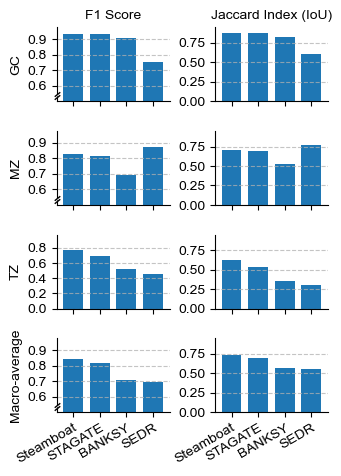

In [16]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(3.5, 5))
gs = GridSpec(4, 2, hspace=.4, wspace=.4, figure=fig)
axes = [fig.add_subplot(gs[0, 0]), 
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[2, 0]),
        fig.add_subplot(gs[3, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, 1]),
        fig.add_subplot(gs[3, 1])]

ax = axes[0]
f1_scores['GC'].plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(0.501, .975)
ax.set_yticks([0.6, 0.7, 0.8, 0.9])
ax.set_title('F1 Score', fontsize=10)
ax.set_xticklabels("")
ax.set_ylabel('GC')

ax = axes[1]
f1_scores['MZ'].plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(0.501, .975)
ax.set_yticks([0.6, 0.7, 0.8, 0.9])
ax.set_xticklabels("")
ax.set_ylabel('MZ')

ax = axes[2]
f1_scores['TZ'].plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(0., .975)
ax.set_yticks([0., 0.2, 0.4, 0.6, 0.8])
ax.set_xticklabels("")
ax.set_ylabel('TZ')

ax = axes[3]
avg_f1_scores = f1_scores.mean(axis=1)
avg_f1_scores.plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(0.501, .975)
ax.set_yticks([0.6, 0.7, 0.8, 0.9])
ax.set_xticklabels(['Steamboat', 'STAGATE', 'BANKSY', 'SEDR'], rotation=30, ha='right', rotation_mode='anchor')
ax.set_ylabel('Macro-average')

ax = axes[4]
iou_scores['GC'].plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(.0, .95)
ax.set_yticks([0.0, 0.25, 0.5, 0.75])
ax.set_title('Jaccard Index (IoU)', fontsize=10)
ax.set_xticklabels("")

ax = axes[5]
iou_scores['MZ'].plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(.0, .95)
ax.set_yticks([0.0, 0.25, 0.5, 0.75])
ax.set_xticklabels("")

ax = axes[6]
iou_scores['TZ'].plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(.0, .95)
ax.set_yticks([0.0, 0.25, 0.5, 0.75])
ax.set_xticklabels("")

ax = axes[7]
avg_iou_scores = iou_scores.mean(axis=1)
avg_iou_scores.plot(kind='bar', width=0.75, ax=ax)
ax.set_ylim(.0, .95)
ax.set_yticks([0.0, 0.25, 0.5, 0.75])
ax.set_xticklabels(['Steamboat', 'STAGATE', 'BANKSY', 'SEDR'], rotation=30, ha='right', rotation_mode='anchor')

for i in [0, 1, 3]:
    ax = axes[i]
    d= .8
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=4, linestyle="none", clip_on=False)
    ax.plot([0], [0.08], transform=ax.transAxes, color='white', **kwargs, zorder=100)
    ax.plot([0], [0.10], transform=ax.transAxes, color='k', **kwargs, zorder=101)
    ax.plot([0], [0.06], transform=ax.transAxes, color='k', **kwargs, zorder=101)

for ax in axes:
    for pos in ['right', 'top']:
        ax.grid(axis='y', linestyle='--', alpha=0.75)
        ax.spines[pos].set_visible(False)

In [ ]:
methods = ['steamboat_spatial_domain_2_labeled', 'stagate_labeled', 'banksy_labeled', 'SEDR_labeled']

from sklearn.metrics import adjusted_rand_score

# density of B_germinal_center in GC region
blind_scores = pd.DataFrame(0, methods, columns=['ARI'])
for method in methods:
    blind_scores.loc[method, 'ARI'] = adjusted_rand_score(adata.obs['cluster'], adata.obs[method])

blind_scores

C:\Users\lshh\AppData\Local\Temp\ipykernel_36964\1478400096.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.39295819446854946' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  blind_scores.loc[method, metric] = fun(adata.obs['cluster'], adata.obs[method])
C:\Users\lshh\AppData\Local\Temp\ipykernel_36964\1478400096.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.36318784452827324' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  blind_scores.loc[method, metric] = fun(adata.obs['cluster'], adata.obs[method])
C:\Users\lshh\AppData\Local\Temp\ipykernel_36964\1478400096.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.27644576309386965' has dtype inco

,ARI,NMI,HS,LISI
steamboat_spatial_domain_2_labeled,0.392958,0.363188,0.276446,0
stagate_labeled,0.359467,0.347120,0.260451,0
banksy_labeled,0.240611,0.288352,0.196097,0
SEDR_labeled,0.243783,0.401454,0.277304,0


,Jaccard index (Macro-average),ARI/NMI summary,ARI,NMI
steamboat_spatial_domain_2_labeled,0.734,0.378,0.393,0.363
stagate_labeled,0.698,0.353,0.359,0.347
banksy_labeled,0.571,0.264,0.241,0.288
SEDR_labeled,0.558,0.323,0.244,0.401


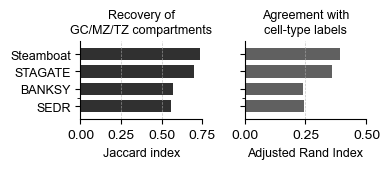

In [22]:
summary_scores = pd.DataFrame({
    'Jaccard index (Macro-average)': iou_scores.mean(axis=1),
    'ARI/NMI summary': blind_scores[['ARI', 'NMI']].mean(axis=1),
    'ARI': blind_scores['ARI'],
    'NMI': blind_scores['NMI'],
})

display(summary_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(4, 1.8), sharey=True)

ax = axes[0]
summary_scores['Jaccard index (Macro-average)'].plot(
    kind='barh', ax=ax, width=0.7, color='#303030'
)
ax.set_xlabel('Jaccard index', fontsize=9)
ax.set_title('Recovery of\nGC/MZ/TZ compartments', fontsize=9)
ax.set_xlim(0, 0.75)
ax.set_xticks([0.0, 0.25, 0.5, 0.75])

ax = axes[1]
summary_scores['ARI'].plot(
    kind='barh', ax=ax, width=0.7, color='#606060'
)
ax.set_xlabel('Adjusted Rand Index', fontsize=9)
ax.set_title('Agreement with\ncell-type labels', fontsize=9)
ax.set_xlim(0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])

for ax in axes:
    ax.set_ylim([len(summary_scores) - 0.25, -0.75])
    ax.grid(axis='x', linestyle='--', alpha=0.75, linewidth=0.5)
    for pos in ['right', 'top']:
        ax.spines[pos].set_visible(False)

axes[0].set_yticklabels(summary_scores.index, fontsize=9)
axes[0].set_yticklabels(['Steamboat', 'STAGATE', 'BANKSY', 'SEDR'], rotation=0, ha='right', rotation_mode='anchor', fontsize=9)

fig.tight_layout()
fig.savefig('figures2/tonsil_spatial_domain_proxy_eval_summary.pdf', **pltkw)